# Pose2 ring SLAM with monolithic and chordal SDP relaxations

GTSAM users typically solve pose-graph SLAM with a nonlinear optimizer initialized near the expected solution. That approach is fast and general, but its result can depend on the initial estimate because rotations make the problem nonconvex.

A certifiable approach rewrites supported factors as a quadratically constrained quadratic program (QCQP) and solves a convex semidefinite programming (SDP) relaxation. The SDP objective is a global lower bound on the QCQP objective. When the lifted SDP solution is numerically rank one, its recovered poses attain that bound and certify a globally optimal QCQP solution, up to numerical tolerance.

This example builds an anchored Pose2 ring, expresses its Frobenius factor graph exactly as a D=1 QCQP, solves monolithic and chordal SDP relaxations with MOSEK, and converts the recovered QCQP vectors to typed Pose2 values.

### Related notebooks

- Start with the [QCQP example](QcqpProblemExample.ipynb) and [QCQP API tutorial](../../../gtsam/constrained/doc/QcqpProblem.ipynb) for the constrained optimization layer.
- See the [lifted SDP overview](../../../gtsam/certifiable/doc/LiftedSDPProblem.ipynb), [monolithic SDP](../../../gtsam/certifiable/doc/MosekMonolithicSDP.ipynb), and [chordal SDP](../../../gtsam/certifiable/doc/MosekChordalSDP.ipynb) notebooks for the certifiable SDP APIs.
- The [Riemannian Staircase optimizer](../../../gtsam/certifiable/doc/RiemannianStaircaseOptimizer.ipynb) documents the Burer–Monteiro alternative.
- The [Rot2](CertifiableRotationAveragingRot2.ipynb) and [Rot3](CertifiableRotationAveragingRot3.ipynb) rotation-averaging examples show the same certifiable pipeline without translation.

GTSAM Copyright 2010-2026, Georgia Tech Research Corporation, Atlanta, Georgia 30332-0415  
All Rights Reserved  
Authors: Frank Dellaert, et al. (see THANKS for the full author list)  
See LICENSE for the license information

<a href="https://colab.research.google.com/github/borglab/gtsam/blob/develop/python/gtsam/examples/Pose2RingSLAMLiftedSDP.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [1]:
try:
    import google.colab
    %pip install --quiet gtsam-develop
except ImportError:
    pass

In [2]:
import numpy as np
import matplotlib.pyplot as plt
import gtsam
from gtsam.symbol_shorthand import X

## Build an exact anchored ring

Frobenius factors compare homogeneous pose matrices, making their squared residuals quadratic in the matrix entries. This structure lets `QcqpProblem` translate the factor graph exactly into a D=1 QCQP.

A hard Frobenius prior fixes the global reference frame and removes gauge freedom. The relative measurements are mutually consistent around the cycle, so the QCQP admits a zero-cost solution at the ground-truth poses. This deliberately simple case makes the recovery and rank-one diagnostics easy to interpret.

In [3]:
# Generate five poses by repeatedly applying one planar motion.
num_poses = 5
step = gtsam.Pose2(2.0, 0.0, 2.0 * np.pi / num_poses)
ground_truth = [gtsam.Pose2()]
for _ in range(1, num_poses):
    ground_truth.append(ground_truth[-1].compose(step))

# Anchor the global frame with a hard prior on the first pose matrix.
graph = gtsam.NonlinearFactorGraph()
graph.add(gtsam.FrobeniusPriorPose2(
    X(0), ground_truth[0].matrix(), gtsam.noiseModel.Constrained.All(9)
))

# Add exact relative-pose measurements, including the closing edge.
for i in range(num_poses):
    j = (i + 1) % num_poses
    graph.add(gtsam.FrobeniusBetweenFactorPose2(
        X(i), X(j), ground_truth[i].between(ground_truth[j]),
        gtsam.noiseModel.Isotropic.Sigma(3, 0.01),
    ))

# Convert the supported Frobenius factors into their exact QCQP form.
problem = gtsam.QcqpProblem(graph)

## Solve both SDP formulations

The SDP relaxation replaces each rank-one outer product with a positive-semidefinite (PSD) matrix. The monolithic formulation collects the entire problem in one PSD cone. The chordal formulation uses the factor graph's sparsity, a METIS ordering, and overlapping clique cones to represent the same relaxation more compactly.

After `solve()`, `qcqpValues()` independently recovers one homogeneous QCQP vector per pose. `variableEVRs()` returns the largest-to-second-largest eigenvalue ratio for each diagonal block; a large ratio indicates that the block is numerically rank one. The appropriate threshold depends on the application and solver tolerances.

In [4]:
# The SDP wrappers are present only in builds configured with MOSEK.
if not hasattr(gtsam, "MosekMonolithicSDP"):
    print("This GTSAM build does not include the optional MOSEK backend.")
    summaries = {}
else:
    # Solve the same QCQP using dense and sparsity-aware relaxations.
    solvers = {
        "monolithic": gtsam.MosekMonolithicSDP(problem),
        "chordal": gtsam.MosekChordalSDP(
            problem, gtsam.ChordalOrderingType.Metis
        ),
    }
    summaries = {}
    for name, solver in solvers.items():
        # A readable MOSEK solution is required before recovery queries.
        if not solver.solve({"intpntCoTolRelGap": 1e-10}):
            raise RuntimeError(f"{name} solve did not return a readable solution")

        # Recover homogeneous vectors, then decode them as typed Pose2 values.
        recovered = gtsam.extractQcqpValuesPose2(solver.qcqpValues())
        errors = np.array([
            np.linalg.norm(ground_truth[i].localCoordinates(recovered.atPose2(X(i))))
            for i in range(num_poses)
        ])

        # Retain accuracy, timing, and rank-one diagnostics for comparison.
        summaries[name] = {
            "objective": solver.objectiveValue(),
            "time": solver.solveTimeSeconds(),
            "errors": errors,
            "evrs": np.asarray(solver.variableEVRs()),
        }
        print(
            f"{name:10s} objective={solver.objectiveValue():.3e}, "
            f"max error={errors.max():.3e}, min EVR={summaries[name]['evrs'].min():.3e}"
        )

monolithic objective=3.119e-07, max error=6.023e-07, min EVR=4.103e+11
chordal    objective=4.640e-07, max error=1.143e-06, min EVR=2.357e+11


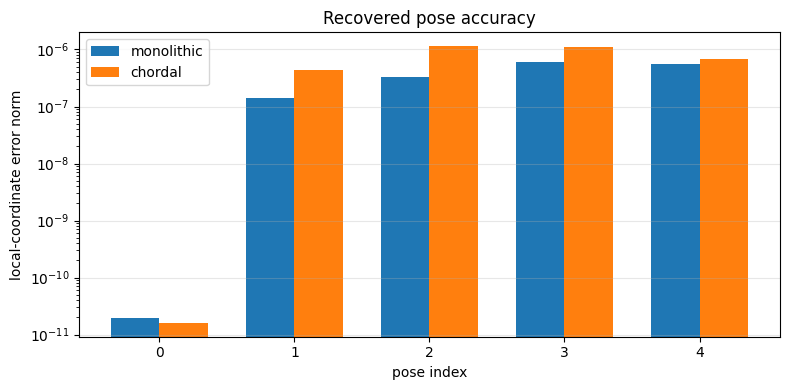

In [5]:
# Compare the pose-wise recovery accuracy of the two formulations.
if summaries:
    indices = np.arange(num_poses)
    width = 0.36
    fig, axis = plt.subplots(figsize=(8, 4))
    axis.bar(
        indices - width / 2,
        summaries["monolithic"]["errors"],
        width,
        label="monolithic",
    )
    axis.bar(
        indices + width / 2,
        summaries["chordal"]["errors"],
        width,
        label="chordal",
    )
    axis.set(
        xlabel="pose index",
        ylabel="local-coordinate error norm",
        title="Recovered pose accuracy",
    )
    axis.set_yscale("log")
    axis.grid(axis="y", alpha=0.3)
    axis.legend()
    plt.tight_layout()

## Reading the result

The objective should be near zero because every measurement is consistent with the anchored ground truth. The monolithic and chordal formulations should report nearly identical objectives and pose errors because they encode the same relaxation.

A large eigenvalue ratio indicates that a diagonal SDP block is effectively rank one, which supports recovering a single QCQP vector from it. Typed extraction then normalizes the homogeneous coordinate, projects the recovered rotation block to the nearest proper rotation, and retains the translation. If the eigenvalue ratios are not sufficiently large, users should treat the recovered poses as a heuristic rather than a certificate.